# Project 3 - Lab 2 - Time Series Data Visualization

In [1]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
sns.set_style('whitegrid')
sns.set_palette('deep')

## Understanding the NGSIM Data

Next Generation Simulation (NGSIM) data (https://ops.fhwa.dot.gov/trafficanalysistools/ngsim.htm) is one of the most influential dataset collected and released by the U.S. Department of Transportation - Federal Highway Administration. The goal of this data is to "To develop a core of open behavioral algorithms in support of traffic simulation with a primary focus on microscopic modeling, including supporting documentation and validation data sets that describe the interactions of multimodal travelers, vehicles and highway systems, and interactions presented to them from traffic control devices, delineation, congestion, and other features of the environment." 

Much of what we know now about driving behavior comes from this dataset. This has a huge impact on the way we design, manage, and operate our transportation system. Similar dataset exists for various commercially available automated vehicles.

In [4]:
# Load the NGSIM dataset
ngsim_data= pd.read_csv('NGSIM.csv')

# Print the dataset and show its attributes
ngsim_data.head()

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,26.654,0.0000,14.054,14.484,1.09730,-3.048000e-02,1
1,0.2,28.060,1.4484,14.164,14.481,-1.00580,-3.048000e-02,1
2,0.3,29.476,2.8965,14.063,14.478,-2.28600,6.096000e-02,1
3,0.4,30.882,4.3443,13.835,14.484,-0.88392,-3.048000e-02,1
4,0.5,32.266,5.7927,13.746,14.481,0.85344,1.780000e-13,1


In [5]:
### Understanding the Data Structure
print("Columns in dataset:", ngsim_data.columns)
print("Dataset info:")
print(ngsim_data.info())


Columns in dataset: Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8166 entries, 0 to 8165
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time                  8166 non-null   float64
 1   leader_position(m)    8166 non-null   float64
 2   follower_position(m)  8166 non-null   float64
 3   leader_speed(m/s)     8166 non-null   float64
 4   follower_speed(m/s)   8166 non-null   float64
 5   leader_acc(m/s^2)     8166 non-null   float64
 6   follower_acc(m/s^2)   8166 non-null   float64
 7   trajectory_number     8166 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 510.5 KB
None


Take some time now, to open the NGSIM.csv excel file and understand the data 


Write here three different observations/knowledge you gathered from the data 
1.  Position are not in terms of x and y coordinates 
2.  There are no missing values
3.  There are 8 columns 

## Exploring the Data Numerically

Before we plot anything, let's use descriptive statistics to understand the range and distribution of values in our dataset. This will help us interpret the graphs later.

In [10]:
# Get descriptive statistics for the full dataset
# This gives us the mean, std, min, max, and quartiles for each column

ngsim_data.describe()

,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
count,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000,8166.000000
mean,27.929611,266.263343,246.576350,8.745533,8.776852,-0.059325,-0.035836,8.176708
std,19.131202,135.110878,134.904708,3.695903,3.784383,1.666269,1.765766,4.811499
min,0.100000,8.227800,0.000000,0.000000,0.000000,-15.240000,-15.240000,1.000000
25%,12.800000,161.337500,141.870000,6.096000,6.096000,-0.365760,-0.365760,4.000000
50%,25.600000,254.180000,237.925000,9.121150,9.128800,0.000000,0.000000,8.000000
75%,38.300000,365.700000,344.990000,12.064000,12.133250,0.335280,0.365760,13.000000
max,84.100000,651.500000,619.050000,17.221000,17.898000,8.046700,15.240000,16.000000


In [11]:
# How many unique trajectory pairs (vehicle pairs) do we have?
# How many time steps does each trajectory have?

# hint: use .groupby('trajectory_number').size() to count rows per trajectory
print(f"number of unique trajectory pairs : {ngsim_data['trajectory_number'].nunique()}")
print()
print("Timestep per trajectory:")
print(ngsim_data.groupby('trajectory_number').size())


number of unique trajectory pairs : 16

Timestep per trajectory:
trajectory_number
1     841
2     398
3     483
4     826
5     401
6     438
7     506
8     394
9     401
10    432
11    447
12    419
13    802
14    448
15    398
16    532
dtype: int64


## Time Series Plottings


Time series data is a sequence of data points recorded at successive time intervals. Plotting time series data means plotting some variable against a time attribute. 
In transportation studies, time series data helps us understand vehicle movement and behavior. 

Let us then start exploring this data


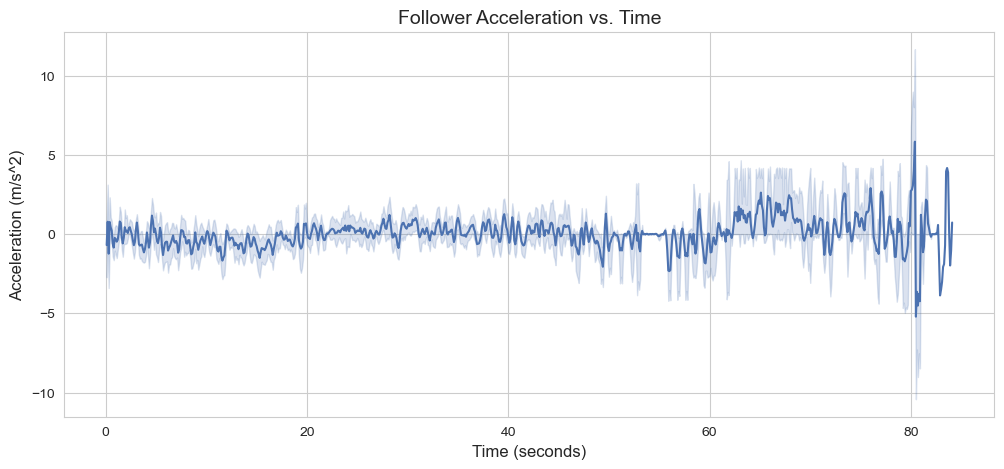

In [14]:
### Plotting Acceleration vs Time

# We are interested in analyzing the acceleration profile of the follower vehicles (follower_acc(m/s^2)) as function of time. Follow the steps we have learned from previous lab to do so. 
# hint we need to use the sns.lineplot 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize=(12,5))
# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x=ngsim_data['Time'], y = ngsim_data['follower_acc(m/s^2)'])

# Step 3: add customizations
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Acceleration (m/s^2)', fontsize=12)
plt.title('Follower Acceleration vs. Time', fontsize=14)

plt.show()



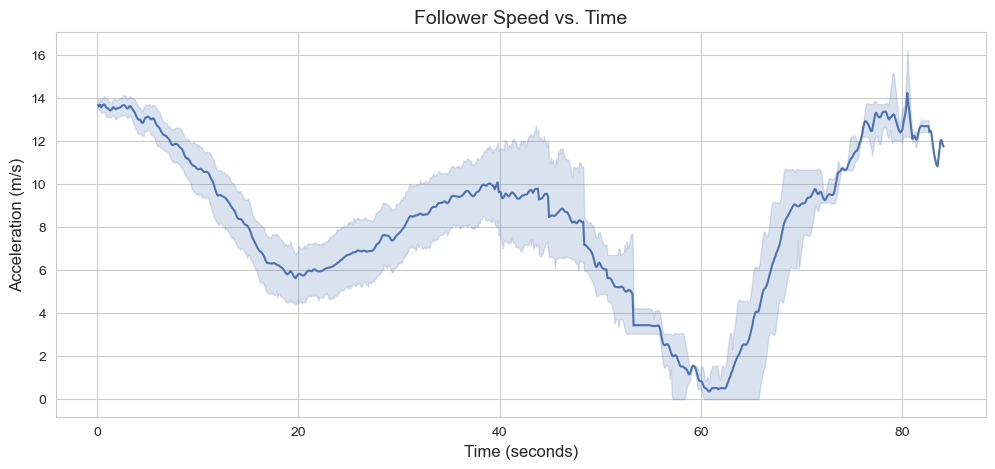

In [15]:
### Plotting Speed vs Time

# replicate the above steps, but now visualize the follower_speed(m/s) data with time 
plt.figure(figsize=(12,5))
sns.lineplot(x=ngsim_data['Time'], y = ngsim_data['follower_speed(m/s)'])

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Acceleration (m/s)', fontsize=12)
plt.title('Follower Speed vs. Time', fontsize=14)

plt.show()


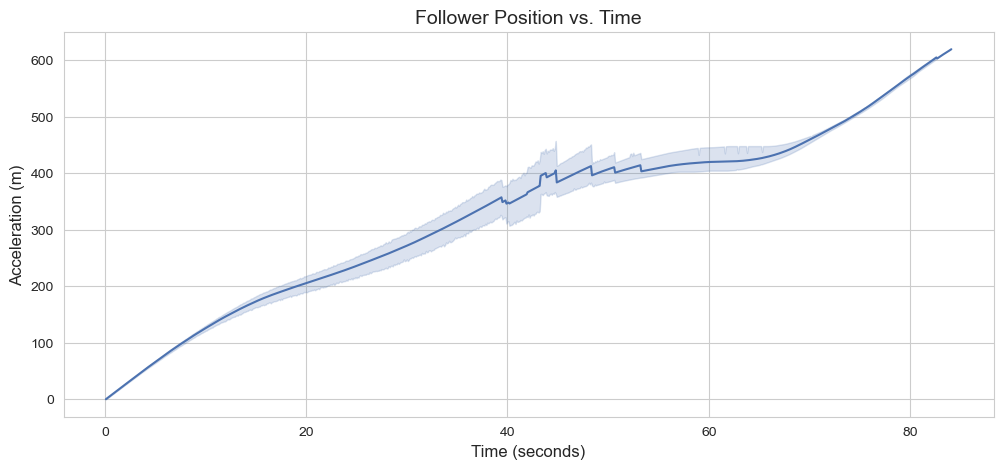

In [16]:
### Plotting Position vs Time

# replicate the above steps, but now visualize the follower_position(m) data with time

plt.figure(figsize=(12,5))
sns.lineplot(x=ngsim_data['Time'], y = ngsim_data['follower_position(m)'])

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Acceleration (m)', fontsize=12)
plt.title('Follower Position vs. Time', fontsize=14)

plt.show()

#similar code, set y to 'follower_position(m)



### Using Subplots for Comparison

A very useful technique in data visualization is **subplots** — placing multiple plots in one figure. This allows us to compare related information side by side.

Let's create a figure with 3 subplots stacked vertically, showing position, speed, and acceleration of the follower vehicle all together. This gives us a complete picture of the vehicle's motion at a glance.

The basic structure is:
```python
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)  # 3 rows, 1 column, shared x-axis
axes[0].plot(...)  # first plot
axes[1].plot(...)  # second plot
axes[2].plot(...)  # third plot
```

## Plotting for each Vehicle Pair Alone


You can notice that we have been plotting all acceleration of different vehicles together. However, if we want to understand vehicle behavior we want to focus on vehicle pair (leader-follower) and learn their characteristics. 

In traffic studies, this is referred to as car-following analysis: how one vehicle follows another in traffic. 

In the following we want to choose some vehicle pair and analyze their behavior

<function matplotlib.pyplot.show(close=None, block=None)>

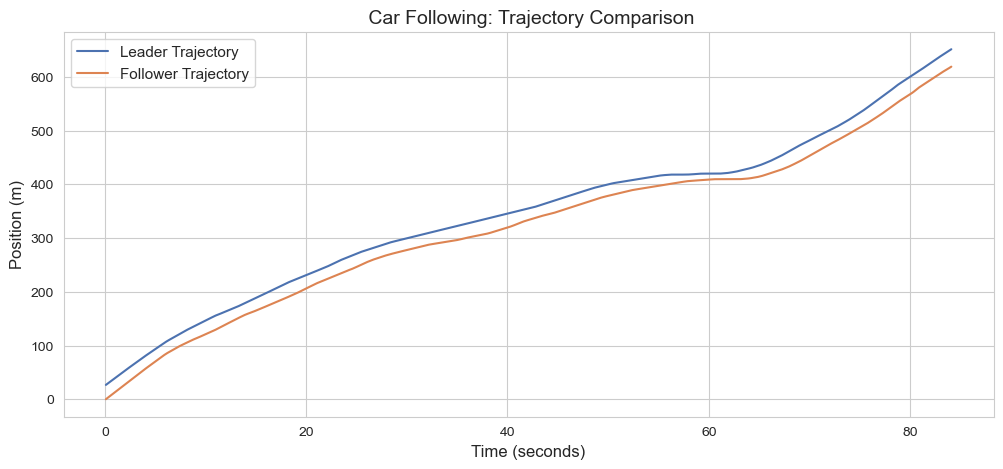

In [21]:
# Select a trajectory number
trajectory_number = 1 # vehicle pair x can choose whatever 1-16

# select the data based on the subset 

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

# Plot the position of both vehicles over time
# follow similar steps of what we learned
# but here you need to plot two lines together:
    # one lineplot for leader position vs time 
    # another lineplot for follower position vs time
plt.figure(figsize=(12,5))
sns.lineplot(x=data_subset['Time'], y = data_subset['leader_position(m)'], label = 'Leader Trajectory')
sns.lineplot(x=data_subset['Time'], y = data_subset['follower_position(m)'], label = 'Follower Trajectory')

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Position (m)', fontsize = 12)
plt.title(' Car Following: Trajectory Comparison', fontsize = 14)
#legends are smaller
plt.legend(fontsize = 11)

plt.show






<function matplotlib.pyplot.show(close=None, block=None)>

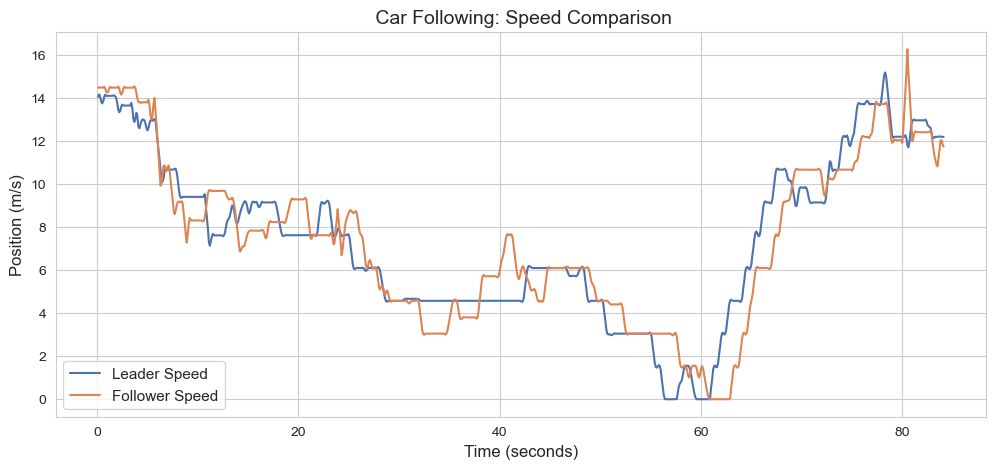

In [22]:
# Now replicate the same but visualizing speed


plt.figure(figsize=(12,5))
sns.lineplot(x=data_subset['Time'], y = data_subset['leader_speed(m/s)'], label = 'Leader Speed')
sns.lineplot(x=data_subset['Time'], y = data_subset['follower_speed(m/s)'], label = 'Follower Speed')

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Position (m/s)', fontsize = 12)
plt.title(' Car Following: Speed Comparison', fontsize = 14)
#legends are smaller
plt.legend(fontsize = 11)

plt.show





<function matplotlib.pyplot.show(close=None, block=None)>

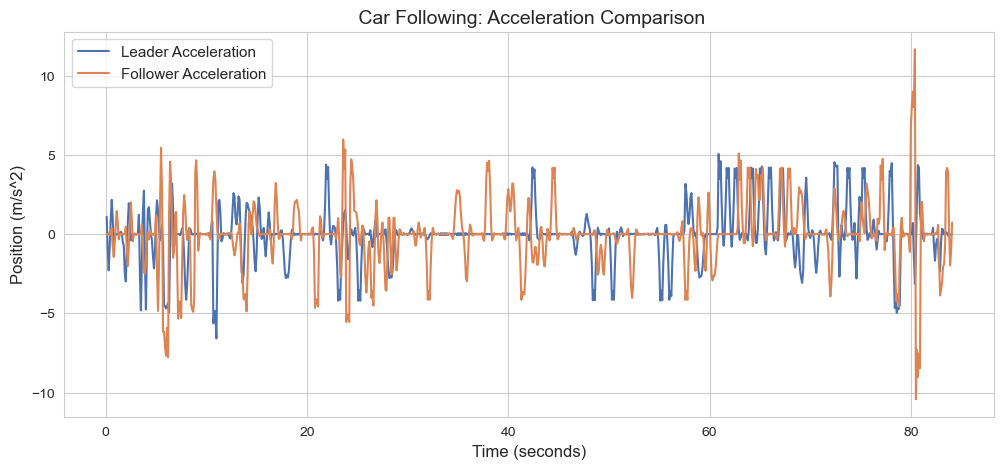

In [23]:
# Now replicating the same but visualizing acceleration

plt.figure(figsize=(12,5))
sns.lineplot(x=data_subset['Time'], y = data_subset['leader_acc(m/s^2)'], label = 'Leader Acceleration')
sns.lineplot(x=data_subset['Time'], y = data_subset['follower_acc(m/s^2)'], label = 'Follower Acceleration')

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Position (m/s^2)', fontsize = 12)
plt.title(' Car Following: Acceleration Comparison', fontsize = 14)
#legends are smaller
plt.legend(fontsize = 11)

plt.show


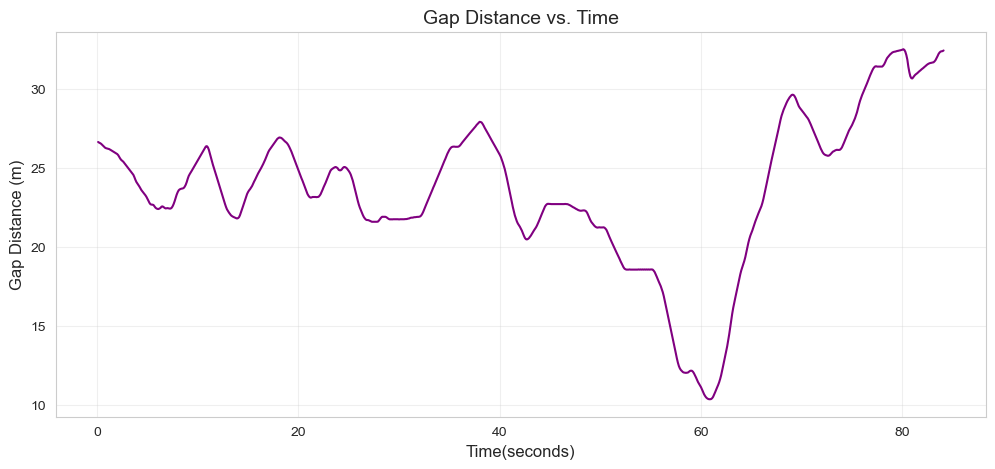

In [24]:
# Now try to plot the gap distance between two vehicle pairs. Gap = position of leader - position of follower
# Plot the gap distance over time 

gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values

plt.figure(figsize = (12,5))
plt.plot(data_subset['Time'], gap_distance, color = 'purple', linewidth = 1.5)
plt.xlabel('Time(seconds)', fontsize = 12)
plt.ylabel('Gap Distance (m)', fontsize = 12)
plt.title('Gap Distance vs. Time', fontsize = 14)
plt.grid(True, alpha = 0.3)
plt.show()


### Comprehensive Vehicle Pair Dashboard

Now let's combine everything we know to create a **comprehensive dashboard** for a vehicle pair. We will use subplots to show trajectory, speed, acceleration, and gap distance all in one figure. This is the kind of analysis a transportation engineer would create to understand car-following behavior.

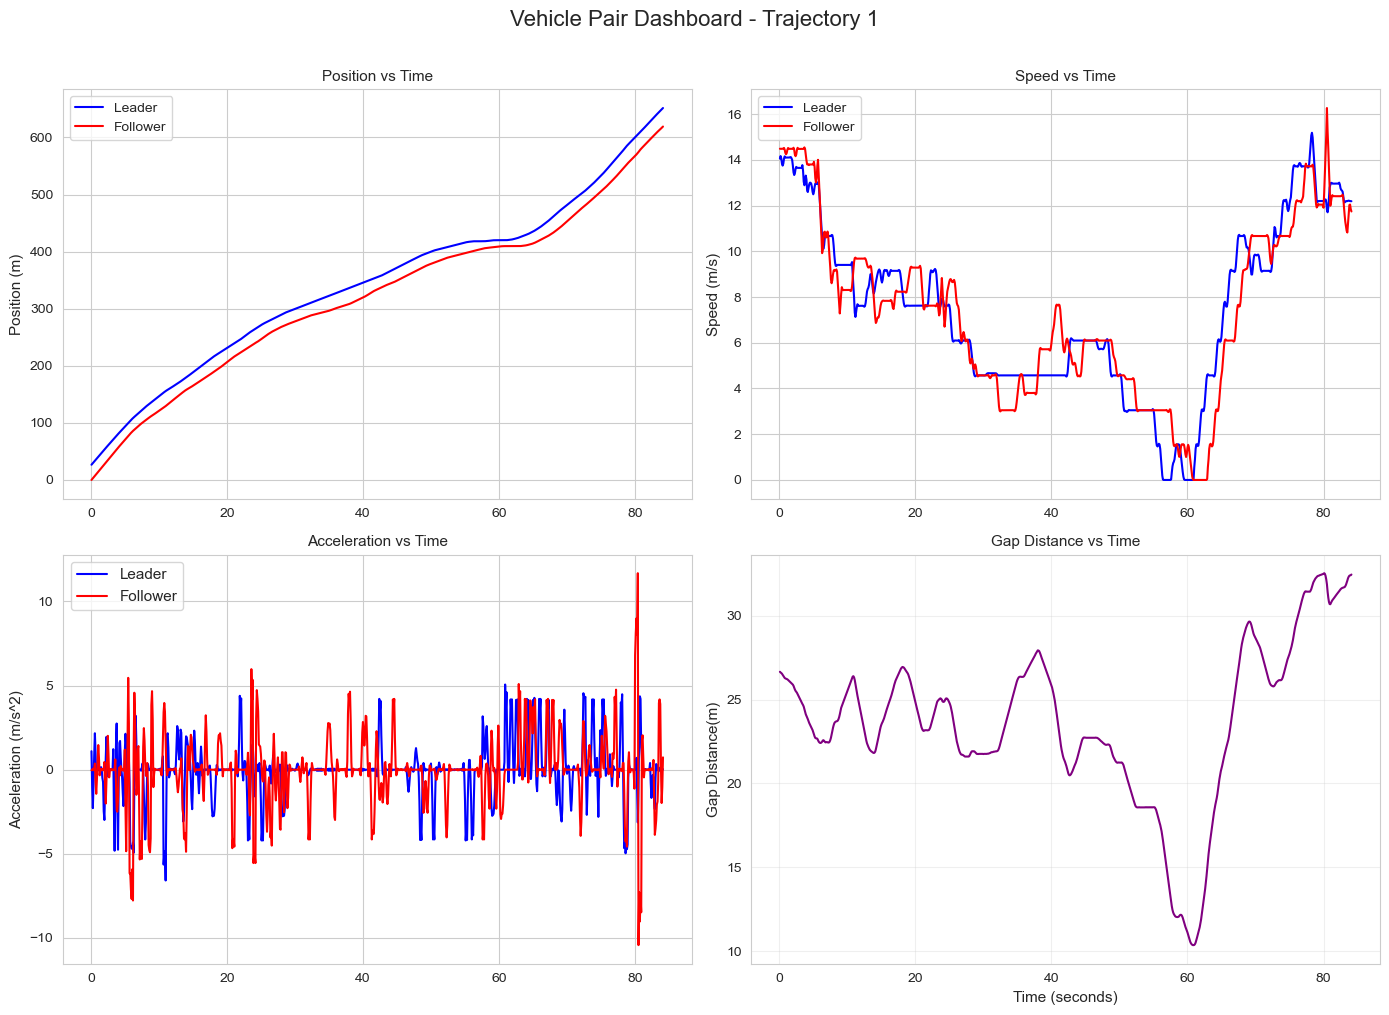

In [27]:
# Create a 2x2 subplot figure showing: trajectory, speed, acceleration, and gap for one vehicle pair

# Step 1: Select a trajectory number and create the subset
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values
time= data_subset['Time'].values

# Step 2: Create the figure with 2 rows and 2 columns
# hint: fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig, axes = plt.subplots(2,2, figsize = (14,10))


# Step 3: Top-left (axes[0,0]): Position vs Time for both leader and follower
axes[0,0].plot(time, data_subset['leader_position(m)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[0,0].plot(time, data_subset['follower_position(m)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[0,0].set_ylabel('Position (m)', fontsize = 11)
axes[0,0].set_title('Position vs Time', fontsize = 11)
axes[0,0].legend(fontsize = 10)

plt.grid(True, alpha = 0.3)
# Step 4: Top-right (axes[0,1]): Speed vs Time for both leader and follower

axes[0,1].plot(time, data_subset['leader_speed(m/s)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[0,1].plot(time, data_subset['follower_speed(m/s)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[0,1].set_ylabel('Speed (m/s)', fontsize = 11)
axes[0,1].set_title('Speed vs Time', fontsize = 11)
axes[0,1].legend(fontsize = 10)

plt.grid(True, alpha = 0.3)
# Step 5: Bottom-left (axes[1,0]): Acceleration vs Time for both leader and follower

axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'].values, 'b-', label = 'Leader', linewidth = 1.5)
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'].values, 'r-', label = 'Follower', linewidth = 1.5)
axes[1,0].set_ylabel('Acceleration (m/s^2)', fontsize = 11)
axes[1,0].set_title('Acceleration vs Time', fontsize = 11)
axes[1,0].legend(fontsize = 11)

plt.grid(True, alpha = 0.3)
# Step 6: Bottom-right (axes[1,1]): Gap Distance vs Time

axes[1,1].plot(time, gap, 'purple', linewidth = 1.5)
axes[1,1].set_xlabel('Time (seconds)', fontsize = 11)
axes[1,1].set_ylabel('Gap Distance(m)', fontsize = 11)
axes[1,1].set_title('Gap Distance vs Time', fontsize = 11)


plt.grid(True, alpha = 0.3)
# Step 7: Add title for the whole figure and adjust layout

plt.suptitle(f'Vehicle Pair Dashboard - Trajectory {trajectory_number}', fontsize = 16, y = 1.01)
plt.tight_layout()
plt.show()
                     

### Comparing Multiple Trajectories

Our dataset contains 16 different vehicle pairs. Let's compare a few trajectories to see how driving behavior varies between different pairs. This is important because not all drivers behave the same way — some follow more closely, some maintain larger gaps, some accelerate more aggressively.

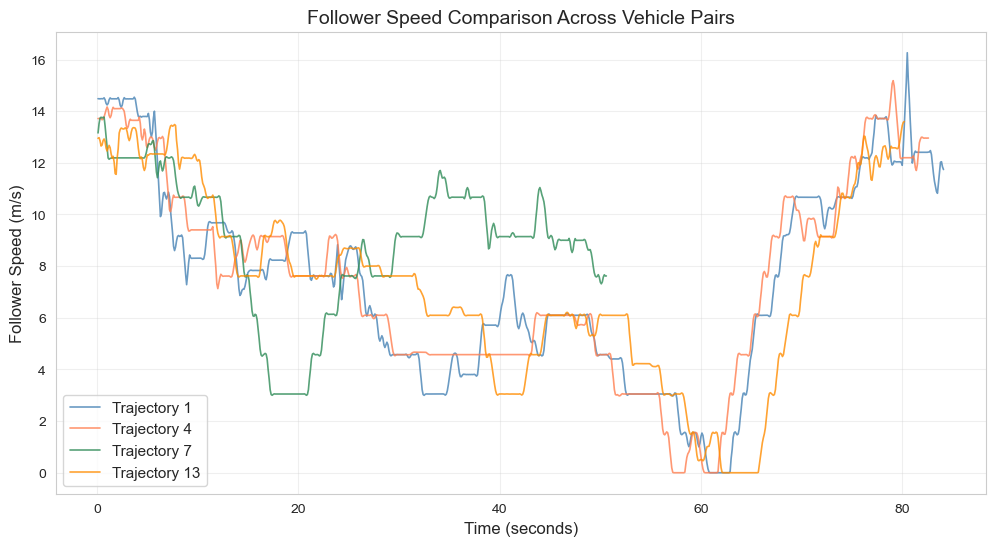

In [30]:
# Compare the follower speed profile for 4 different trajectory pairs on the same plot
# This shows us the variation in driving behavior across different vehicle pairs

# hint: loop through trajectory_numbers = [1, 4, 7, 13]
# for each one, filter the data and plot the follower speed vs time

trajectory_numbers = [1, 4, 7, 13]

colors = ['steelblue', 'coral', 'seagreen', 'darkorange']
plt.figure(figsize = (12,6))



for traj, color in zip (trajectory_numbers, colors):
    subset = ngsim_data[ngsim_data['trajectory_number'] == traj]
    plt.plot(subset['Time'].values, subset['follower_speed(m/s)'].values,
            color=color, linewidth = 1.2, label = f'Trajectory {traj}', alpha = 0.8)

plt.xlabel('Time (seconds)', fontsize =12)
plt.ylabel('Follower Speed (m/s)', fontsize = 12)
plt.title('Follower Speed Comparison Across Vehicle Pairs', fontsize = 14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()


Write your observations about the differences between trajectories:
1. Do all trajectories have the same duration? Why might they differ?

   
   
3. Which trajectory shows the most variation in speed?

   Trajectory 1 
   
4. What can the speed range tell us about the traffic conditions each pair experienced?

   How traffic condition changes. Like if traffic conditions are smooth or if its rough.
   

## Analysis of Vehicle Behavior


Remember in our previous lab, we learned how to generate histogram, boxplots, and bar graphs. Now some of these graphs can help us understand the driving behavior. 

Let us explore these in the following


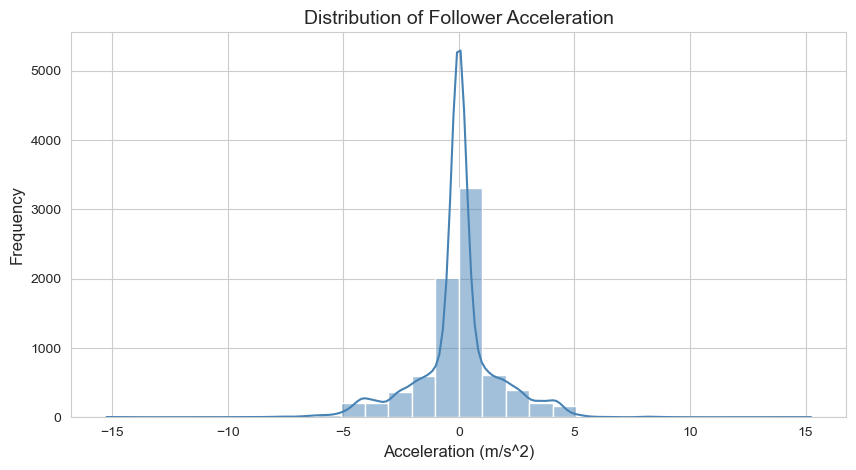

In [34]:
## Here you are asked to show a histogram of the acceleration. Specifically, we want to see how acceleration values are distributed for the following cars
# here try to use the sns.histplot graph 

plt.figure(figsize = (10,5))
sns.histplot(ngsim_data['follower_acc(m/s^2)'], bins=30, kde = True, color = 'steelblue')
plt.xlabel('Acceleration (m/s^2)', fontsize = 12)
plt.ylabel('Frequency', fontsize = 12)
plt.title('Distribution of Follower Acceleration', fontsize = 14)
plt.show()

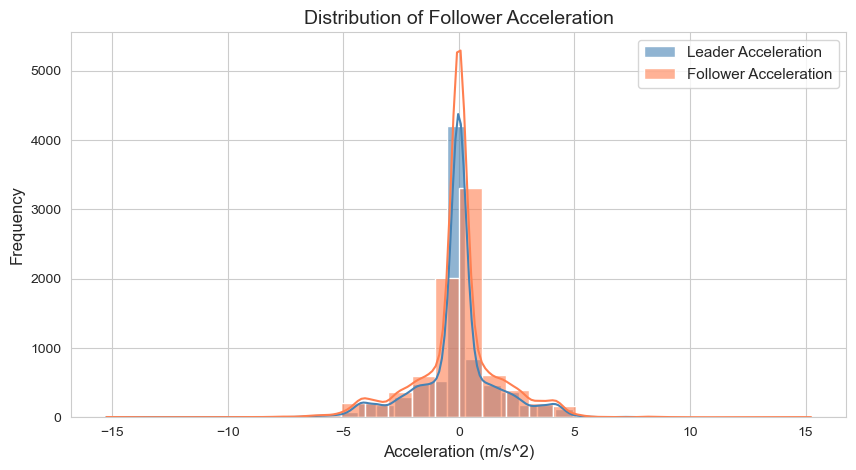

In [35]:
# What if we want to visualize how the distribution of acceleration changes between leader and follower
# Plot the two histplot of leader and follower on same plot 

plt.figure(figsize = (10,5))

# This histogram compares the distribution of acceleration for leader and follower vehicles on the same plot.
sns.histplot(ngsim_data['leader_acc(m/s^2)'], bins=30, kde = True, label = 'Leader Acceleration', color = 'steelblue', alpha = 0.6)
sns.histplot(ngsim_data['follower_acc(m/s^2)'], bins=30, kde = True, label = 'Follower Acceleration', color = 'coral', alpha = 0.6)


# Customize the plot
plt.xlabel('Acceleration (m/s^2)', fontsize = 12)
plt.ylabel('Frequency', fontsize = 12)
plt.title('Distribution of Follower Acceleration', fontsize = 14)
plt.legend(fontsize = 11)
plt.show()

Now you can see that the distribution figure allows us to visualize how acceleration changes between leader and follower. Yet, we can make the figure clearer by using scatterplots. Scatterplots, plot each point alone as a coordinate (i,e., (x,y,z,etc..)) and helps us understand how individual data is distributed along different dimensions. Let us try it out

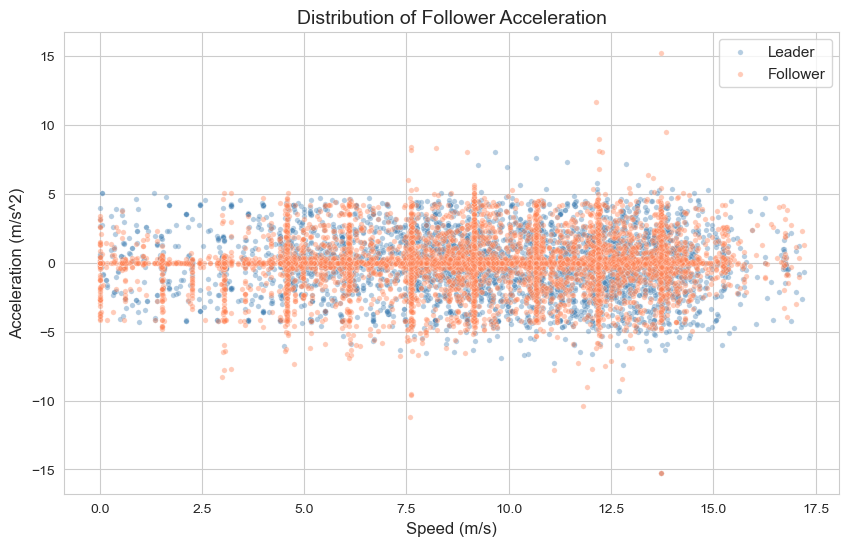

In [42]:
# We want to understand how acceleration changes with speed for both leader and follower vehicles. 

# create graph that uses sns.scatterplot to visualize:
    # speed on x axis
    # acceleration on y axis 
    # showing both leader and follower data 



# This scatter plot visualizes how acceleration changes with speed for both leader and follower vehicles.
plt.figure(figsize=(10,6))

sns.scatterplot(x=ngsim_data['leader_speed(m/s)'], y = ngsim_data['leader_acc(m/s^2)'], label = 'Leader', alpha = 0.4, color = 'steelblue', s =15)
sns.scatterplot(x=ngsim_data['leader_speed(m/s)'], y = ngsim_data['follower_acc(m/s^2)'], label = 'Follower', alpha = 0.4, color = 'coral', s =15)

plt.xlabel('Speed (m/s)', fontsize = 12)
plt.ylabel('Acceleration (m/s^2)', fontsize = 12)
plt.title('Distribution of Follower Acceleration', fontsize = 14)
plt.legend(fontsize = 11)
plt.show()

## Heatmap Trajectory Visualization

Now, one of the most useful plots for an engineer are HeatMaps. Heatmaps are very versatile and can be used in many different ways. One way I like to use them is to add a layer of information to any plot. Think about the heatmap values as a third invisible dimension. 

Let us see how that works. 

Recall the trajectory plot of two pair of vehicles we did at the beginning, let us try to replicate that but we want to color the trajectory based on speed value.

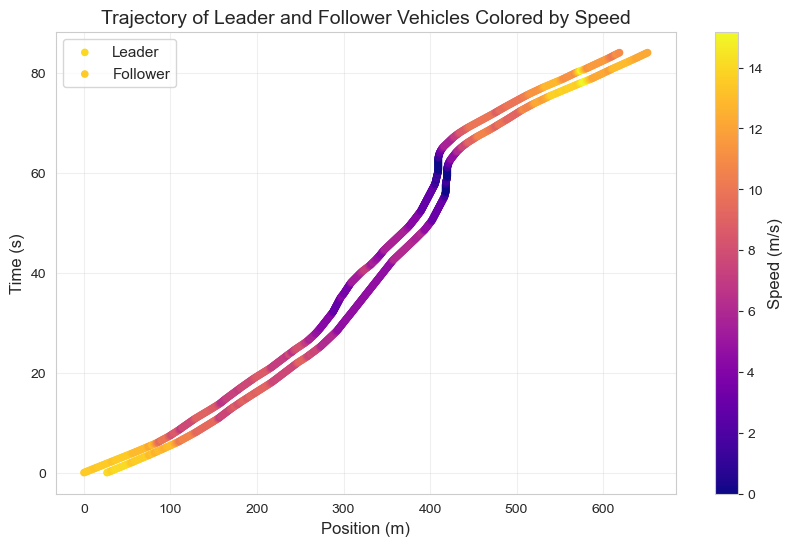

In [68]:
# Step 1: Select a trajectory number
trajectory_number = 1

# Step 2: Select the data based on the subset
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

time = data_subset['Time'].values

# Step 3: Tell python you want to plot a figure and assign a size 
plt.figure(figsize=(10,6))

# Step 4: Create a scatter plot for leader vehicle of position vs. time. 
    # however to this plot we want to add a colormap that is based on leader_speed(m/s) data
    # use cmap=plasma to specify the colors
leader_position = data_subset['leader_position(m)'].values
follower_position = data_subset['follower_position(m)'].values

leader_speed = data_subset['leader_speed(m/s)'].values
follower_speed = data_subset['follower_speed(m/s)'].values

# Step 3: Create scatter plots colored by speed
leader_plot = plt.scatter(
    leader_position,
    time,
    c=leader_speed,
    cmap='plasma',
    s=20,
    label='Leader'
)

follower_plot = plt.scatter(
    follower_position,
    time,
    c=follower_speed,
    cmap='plasma',
    s=20,
    label='Follower'
)
#had chatgpt help me for this step 

# Add colorbar to indicate speed values
colorbar = plt.colorbar(leader_plot)
colorbar.set_label('Speed (m/s)', fontsize=12)

#had chatgpt help me in this one too 

# Labels and title

plt.xlabel('Position (m)', fontsize=12)
plt.ylabel('Time (s)', fontsize=12)
plt.title('Trajectory of Leader and Follower Vehicles Colored by Speed', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()



## Summary

In this lab you have learned:
1. How to create time series plots to visualize vehicle motion (position, speed, acceleration)
2. How to use **subplots** to create comprehensive multi-panel figures
3. How to analyze individual vehicle pairs (car-following behavior)
4. How to compare behavior across multiple trajectory pairs
5. How to use histograms and scatter plots to analyze driving behavior distributions
6. How to create heatmap-colored trajectories and space-time diagrams

These visualization skills are essential tools for transportation engineers analyzing traffic data.